In [8]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path
import seaborn as sns

from matplotlib.ticker import FuncFormatter


sns.set_theme(style="whitegrid", rc={"figure.dpi": 300, "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10, "legend.fontsize": 8})


def extract_single_data(df):
    data = {}
    data["state_cost"] = df["state_cost"].to_numpy()
    data["success"] = df["success"].to_numpy()
    data["T_pos"] = np.array([eval(x) for x in df["qpos"]])[:, :3]
    data["control"] = np.array([eval(x) for x in df["control"]])
    data["domain_weights"] = np.array([eval(x) for x in df["domain_weights"]])
    return data

def extract_values(path, seeds, controllers):
    data: Dict[int, Dict[str, Dict[str, np.ndarray]]] = {}
    missing: list[str] = []

    for seed in seeds:
        data[seed] = {}
        for controller in controllers:
            # file = path / f"{controller}/seed_{seed}_update_cov_True.csv"
            file = path / f"seed_{seed}_update_cov_True.csv"
            if not file.exists():
                missing.append(str(file))
                continue
            df = pd.read_csv(file)
            data[seed][controller] = extract_single_data(df)

    if missing:
        print("[plot_seeds] Skipped missing files:\n  - " + "\n  - ".join(missing))
    # Safety: filter seeds with at least one controller present
    seeds_present = [s for s in seeds if len(data.get(s, {})) > 0]
    if not seeds_present:
        raise FileNotFoundError("No seed data found. Check paths and filenames.")
    return data


In [9]:
path = get_data_path().parent / "experiments" / "online_dr_sim"

seeds = [42] 
controllers = ["anmtp"]
data = extract_values(path, seeds, controllers)

In [20]:
pprint.pprint(data[42]["anmtp"]["domain_weights"])


array([[0.05      , 0.05      , 0.05      , ..., 0.05      , 0.05      ,
        0.05      ],
       [0.05      , 0.05      , 0.05      , ..., 0.05      , 0.05      ,
        0.05      ],
       [0.03150608, 0.04941499, 0.04934567, ..., 0.04355006, 0.04337763,
        0.04285656],
       ...,
       [0.04999999, 0.04999999, 0.04999999, ..., 0.04999999, 0.04999999,
        0.04999999],
       [0.04999999, 0.04999999, 0.04999999, ..., 0.04999999, 0.04999999,
        0.04999999],
       [0.04877599, 0.04002665, 0.04079618, ..., 0.05733903, 0.0590041 ,
        0.05959041]], shape=(109, 20))


/home/magnus/miniconda3/envs/mtp-thesis/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/magnus/miniconda3/envs/mtp-thesis/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/home/magnus/miniconda3/envs/mtp-thesis/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/home/magnus/miniconda3/envs/mtp-thesis/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/ho

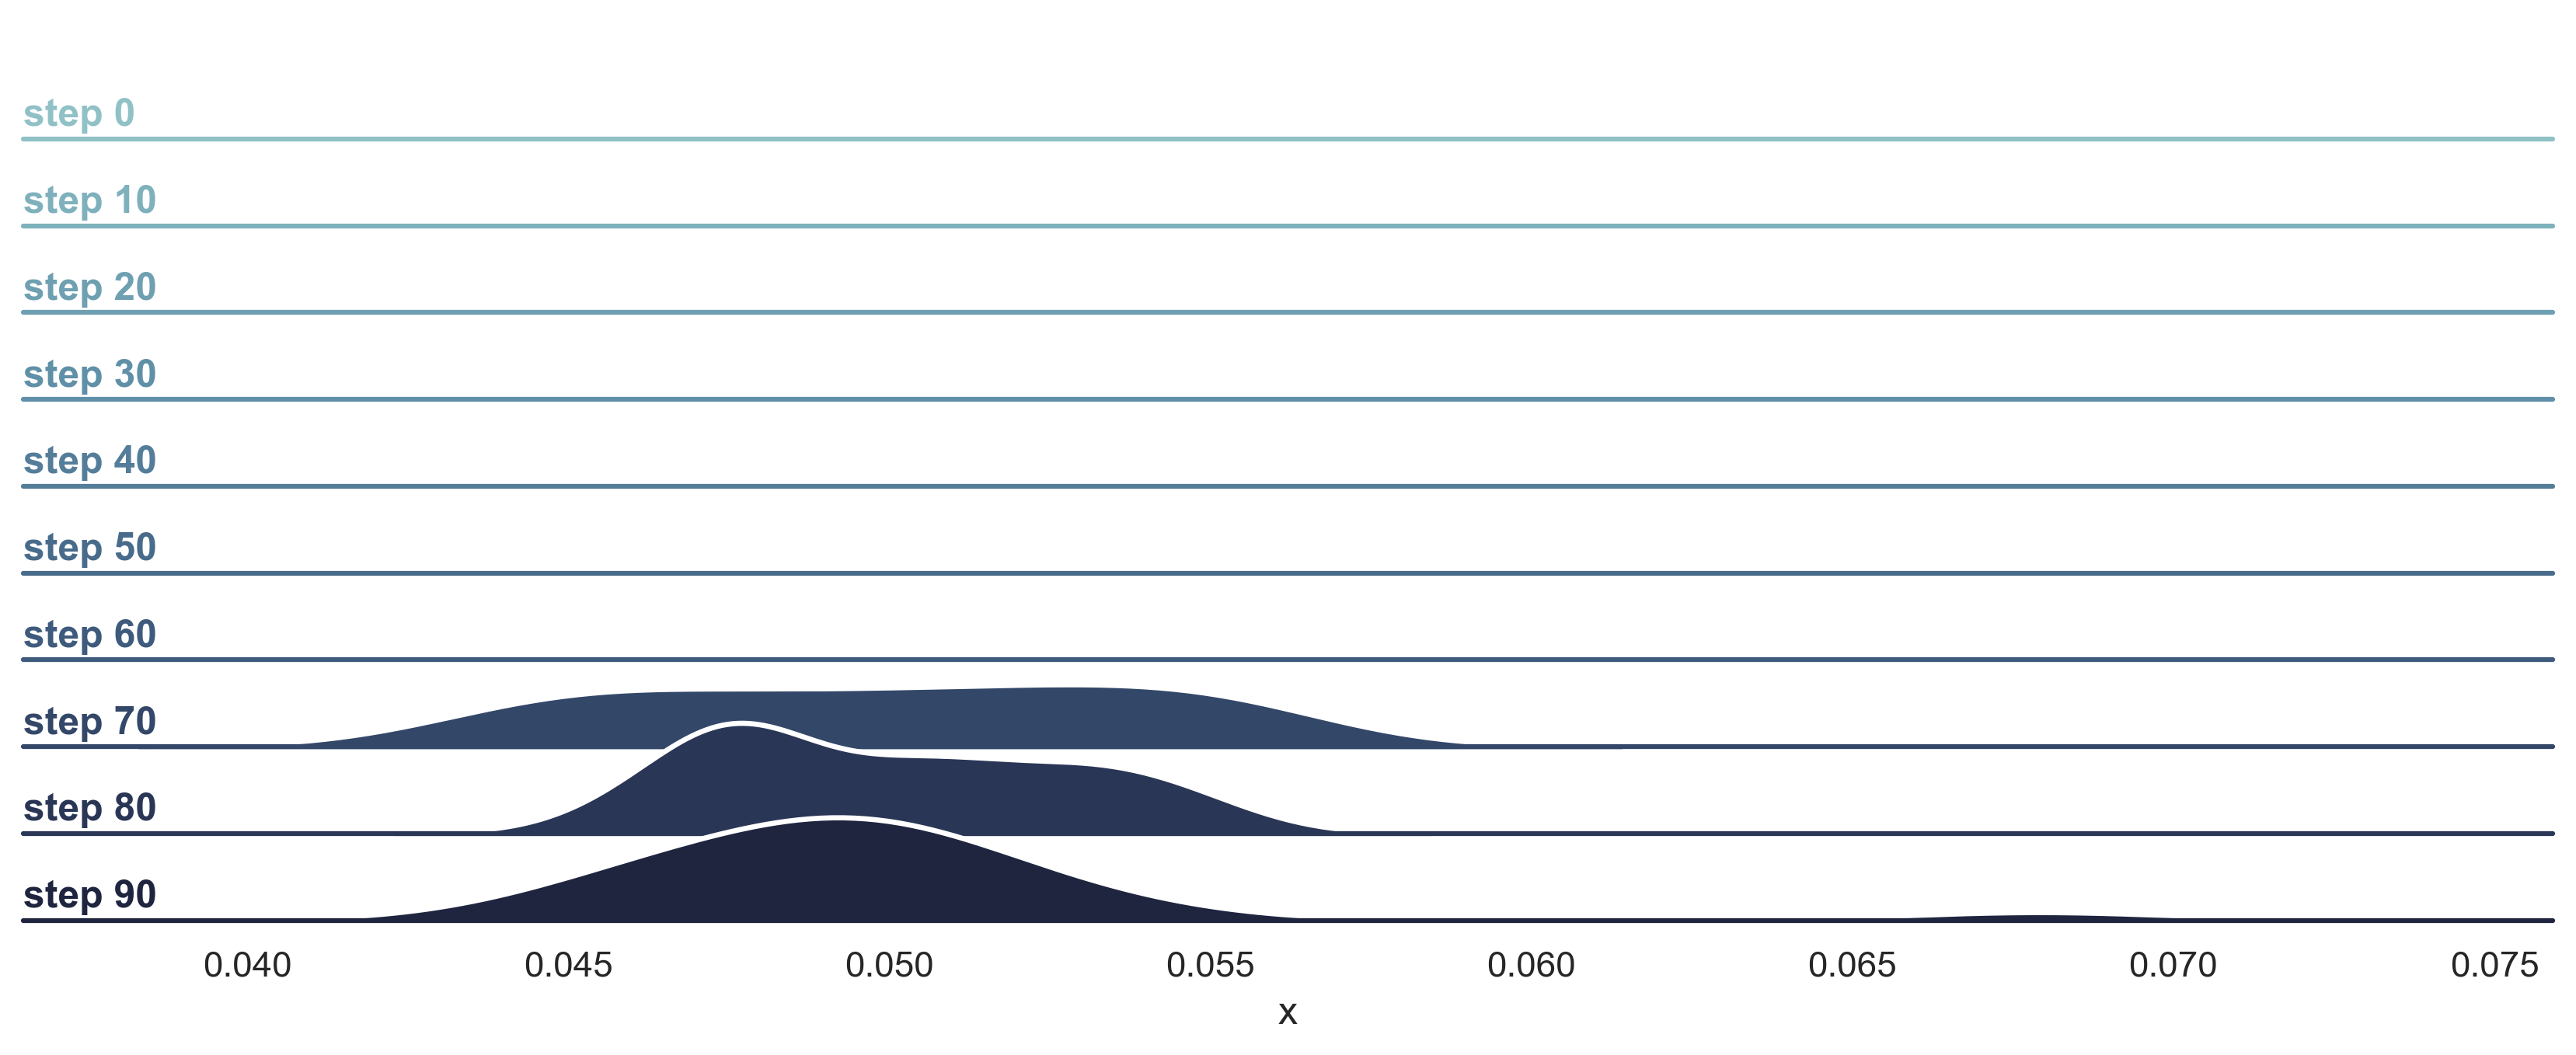

In [19]:
X = data[42]["anmtp"]["domain_weights"]

steps, samples = X.shape
height=0.5
aspect=14
bw_adjust=0.8
step_idx = [10*i for i in range(10)]  # Plot every 10th step


if step_idx is None:
    step_idx = list(range(steps))
# Build long DataFrame
df = pd.DataFrame({
    "x": X[step_idx].ravel(),
    "step": np.repeat(step_idx, samples)
})
# Make string labels so FacetGrid preserves order nicely
df["label"] = pd.Categorical([f"step {s}" for s in df["step"]], 
                                categories=[f"step {s}" for s in step_idx],
                                ordered=True)

palette = sns.cubehelix_palette(len(step_idx), rot=-0.25, light=0.7)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df, row="label", hue="label", aspect=aspect/height, height=height, palette=palette)

# Filled KDE and outline
g.map(sns.kdeplot, "x", bw_adjust=bw_adjust, clip_on=False, fill=True, alpha=1, linewidth=1.25)
g.map(sns.kdeplot, "x", bw_adjust=bw_adjust, clip_on=False, color="w", lw=1.6)

# Baseline per ridge
g.refline(y=0, linewidth=1.5, linestyle="-", color=None, clip_on=False)

# Inline ridge labels
def _label(x, color, label, **kws):
    ax = plt.gca()
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(_label, "x")

g.figure.subplots_adjust(hspace=-0.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.show()